# Mu Torere (Radiance) (3×3 Grid Version)

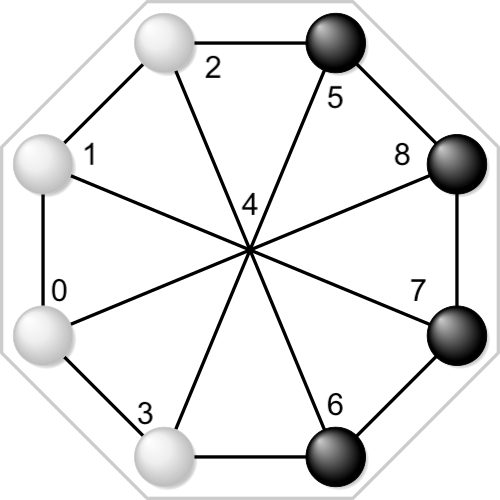


## Board Numbering
```
0 | 1 | 2
--+---+--
3 | 4 | 5
--+---+--
6 | 7 | 8
```

- **Center (4)** = hub (*putahi*).  
- **Outer (0,1,2,3,5,6,7,8)** = ring.  

--


---

## Setup
- Two players, each with **4 pieces** (● and ○).  
- Pieces are placed as shown around the ring.  
- Square **4** starts empty.  

Example sequence setup:
```
○ | ○ | ○
--+---+--
○ | ⊙ | ●
--+---+--
● | ● | ●
```

Example alternating setup:
```
○ | ● | ○
--+---+--
● | ⊙ | ●
--+---+--
○ | ● | ○
```

---

## Moves
1. Players alternate turns.  
2. A piece may move into **square 4** if it is empty and adjacent.  
3. A piece on the ring may move into an **empty ring square** *only if* it is directly **next to an opponent’s piece**  
   (adjacent horizontally, vertically, or diagonally).
4. Note that each ring square is connected to the **nearest three** ring squares, not all adjacent.  For example, square 0 is connected to 1, 3, and 4 while square 1 is connected to 0, 4, and 2.|
5. A piece in **square 4** may move into any **adjacent empty ring square**.  

---

## Goal
- **Win by blocking your opponent** so they cannot make a legal move.  
- There is no capturing — victory is achieved through movement and positioning.  


In [1]:
from Game import *

Version:  0.3.15


# Game functions

In [2]:
def initial_state():
    state=Board(3,3)

    for location in [0,2,6,8]:
        state[location]=1
    for location in [1,3,7,5]:
        state[location]=2

    state.pieces=[".","○","●"]

    return state
    

In [3]:
initial_state()

 ○  ●  ○ 
 ●  .  ● 
 ○  ●  ○ 

In [4]:
def show_state(state,player):
    print("Current board for player ",player)
    print(state)

In [5]:
state=initial_state()
show_state(state,1)

Current board for player  1
 ○  ●  ○ 
 ●  .  ● 
 ○  ●  ○ 



In [6]:
state.show_locations()

 0  1  2 
 3  4  5 
 6  7  8 



- what is state -- board 3x3, 0 = empty, 1=player 1, 2=player 2
- what is move -- [1,4]  another [2,4]   [start,end]
- what is a list of moves -- [  [1,4], [2,4], ]

What constitutes the move to be valid in this game:

- loop through all start locations
- at each start location, check see if state[start location]==player 
- for each start, loop through all of the end locations (go through the adjacent locations)
- check state[end]==0, check to see that end is adjacent to start
- check adjacent locations to the end location has to have other player
- moves.append([start,end])

In [7]:
def adjacent_squares(location):
    # return a list of all the adjacent locations

    if location==0:
        return [1,3,4]
    if location==1:
        return [0,2,4]
    if location==2:
        return [1,5,4]
    if location==3:
        return [0,6,4]
    if location==4:
        return [0,1,2,3,4,5,6,7,8]
    if location==5:
        return [2,8,4]
    if location==6:
        return [3,7,4]
    if location==7:
        return [6,8,4]
    if location==8:
        return [5,7,4]

    raise ValueError("You can't get there from here.")


In [8]:
def valid_moves(state,player):
    # return a **list** of moves that are valid
    if player==1:
        other_player=2
    else:
        other_player=1

    moves=[]
    for start in range(9):
        if state[start]!=player:
            continue

        for end in adjacent_squares(start):
            if state[end]!=0:
                continue

            good_move=False
            for adj in adjacent_squares(end):
                if state[adj]==other_player:
                    good_move=True

            if good_move:
                moves.append([start,end])


    return moves

In [9]:
state=initial_state()
valid_moves(state,1)

[[0, 4], [2, 4], [6, 4], [8, 4]]

In [10]:
state=initial_state()
state[3]=0
state[2]=0
state[6]=0
state[7]=0
state

 ○  ●  . 
 .  .  ● 
 .  .  ○ 

In [11]:
valid_moves(state,1)

[[0, 4], [8, 4]]

In [12]:
def update_state(state,player,move):
    start,end=move

    new_state=state
    new_state[start]=0
    new_state[end]=player

    return new_state

In [13]:
def win_status(state,player):
    # called after update_state
    # returns "win" if this new state is a win for this player
    # returns "lose" if this new state is a loss for this player
    # returns "stalemate" if this new state is a tie for this player
    # return None if this is a mid-game state

    if player==1:
        other_player=2
    else:
        other_player=1
    
    if not valid_moves(state,other_player):
        return "win"
        

# Agents

In [14]:
def random_move(state,player):
    moves=valid_moves(state,player)
    return random.choice(moves)

random_agent=Agent(random_move)

In [15]:
def human_move(state,player):
    moves=valid_moves(state,player)
    print("Valid moves are: ",moves)
    move=eval(input("Enter your move:"))
    while move not in moves:
        print("Invalid move...try again")
        move=eval(input("Enter your move:"))

    return move

human_agent=Agent(human_move)    

# Running the game

In [16]:
g=Game()
g.run(random_agent,random_agent)

====
Game  1
Current board for player  1
 ○  ●  ○ 
 ●  .  ● 
 ○  ●  ○ 

Player 1 moves [2, 4]
Current board for player  2
 ○  ●  . 
 ●  ○  ● 
 ○  ●  ○ 

Player 2 moves [1, 2]
Current board for player  1
 ○  .  ● 
 ●  ○  ● 
 ○  ●  ○ 

Player 1 moves [4, 1]
Current board for player  2
 ○  ○  ● 
 ●  .  ● 
 ○  ●  ○ 

Player 2 moves [7, 4]
Current board for player  1
 ○  ○  ● 
 ●  ●  ● 
 ○  .  ○ 

Player 1 moves [8, 7]
Current board for player  2
 ○  ○  ● 
 ●  ●  ● 
 ○  ○  . 

Player 2 moves [4, 8]
Current board for player  1
 ○  ○  ● 
 ●  .  ● 
 ○  ○  ● 

Player 1 moves [1, 4]
Current board for player  2
 ○  .  ● 
 ●  ○  ● 
 ○  ○  ● 

Player 2 moves [2, 1]
Current board for player  1
 ○  ●  . 
 ●  ○  ● 
 ○  ○  ● 

Player 1 moves [4, 2]
Current board for player  2
 ○  ●  ○ 
 ●  .  ● 
 ○  ○  ● 

Player 2 moves [5, 4]
Current board for player  1
 ○  ●  ○ 
 ●  ●  . 
 ○  ○  ● 

Player 1 moves [2, 5]
Current board for player  2
 ○  ●  . 
 ●  ●  ○ 
 ○  ○  ● 

Player 2 moves [1, 2]
Current board f

[1]

In [17]:
g=Game()
g.run(random_agent,human_agent)

====
Game  1
Current board for player  1
 ○  ●  ○ 
 ●  .  ● 
 ○  ●  ○ 

Player 1 moves [8, 4]
Current board for player  2
 ○  ●  ○ 
 ●  ○  ● 
 ○  ●  . 

Valid moves are:  [[5, 8], [7, 8]]


Enter your move: [7,8]


Player 2 moves [7, 8]
Current board for player  1
 ○  ●  ○ 
 ●  ○  ● 
 ○  .  ● 

Player 1 moves [6, 7]
Current board for player  2
 ○  ●  ○ 
 ●  ○  ● 
 .  ○  ● 

Valid moves are:  [[3, 6]]


Enter your move: [3,6]


Player 2 moves [3, 6]
Current board for player  1
 ○  ●  ○ 
 .  ○  ● 
 ●  ○  ● 

Player 1 moves [0, 3]
Current board for player  2
 .  ●  ○ 
 ○  ○  ● 
 ●  ○  ● 

Valid moves are:  [[1, 0]]


...

Player 2 moves [1, 0]
Current board for player  1
 ●  .  ○ 
 ○  ○  ● 
 ●  ○  ● 

Player 1 moves [4, 1]
Current board for player  2
 ●  ○  ○ 
 ○  .  ● 
 ●  ○  ● 

Valid moves are:  [[0, 4], [5, 4], [6, 4], [8, 4]]


Enter your move: 5


Invalid move...try again


Enter your move: 


SyntaxError: invalid syntax (<string>, line 0)